# Classical Simulation

[Official documentation](https://qualtran.readthedocs.io/en/latest/simulation/classical_sim.html)

### Basics

In [2]:
from qualtran.bloqs.basic_gates import CNOT

cnot = CNOT()
cnot.call_classically(ctrl=1, target=0)


(1, 1)

### Interface

In [4]:
import itertools

for c, t in itertools.product([0,1], repeat=2):
    out_c, out_t = CNOT().call_classically(ctrl=c, target=t)
    print(f'{c}{t} -> {out_c}{out_t}')

00 -> 00
01 -> 01
10 -> 11
11 -> 10


### Additional Functionality

In [5]:
from qualtran import QUInt
from qualtran.bloqs.arithmetic import Add

add = Add(QUInt(8))
add.call_classically(a=5, b=7)

(5, 12)

In [6]:
import numpy as np
rs = np.random.RandomState(seed=52)

add_cbloq = add.decompose_bloq()

for _ in range(10):
    a = rs.randint(256)
    b = rs.randint(256)
    ref_vals = add.call_classically(a=a, b=b)
    decomp_vals = add_cbloq.call_classically(a=a, b=b)
    assert ref_vals == decomp_vals
    print('✓', end='')

✓✓✓✓✓✓✓✓✓✓

In [8]:
import qualtran.testing as qlt_testing

dtye = QUInt(2)
qlt_testing.assert_consistent_classical_action(
    bloq=Add(dtye),
    a=dtye.get_classical_domain(),
    b=dtye.get_classical_domain(),
)
print('✓')

✓


In [9]:
from qualtran.simulation.classical_sim import get_classical_truth_table, format_classical_truth_table
from qualtran.bloqs.arithmetic import Add
from qualtran import QUInt

add = Add(QUInt(2))
print(format_classical_truth_table(*get_classical_truth_table(add)))

a  b  |  a  b
--------------
0, 0 -> 0, 0
0, 1 -> 0, 1
0, 2 -> 0, 2
0, 3 -> 0, 3
1, 0 -> 1, 1
1, 1 -> 1, 2
1, 2 -> 1, 3
1, 3 -> 1, 0
2, 0 -> 2, 2
2, 1 -> 2, 3
2, 2 -> 2, 0
2, 3 -> 2, 1
3, 0 -> 3, 3
3, 1 -> 3, 0
3, 2 -> 3, 1
3, 3 -> 3, 2


### Implementation

In [10]:
from typing import *

import numpy as np
from attrs import frozen
from numpy.typing import NDArray

from qualtran import Bloq, BloqBuilder, Register, Signature, Side
from qualtran.drawing import show_bloq


@frozen
class CNOTExample(Bloq):
    @property
    def signature(self) -> 'Signature':
        return Signature.build(ctrl=1, target=1)

    def on_classical_vals(
        self, ctrl: NDArray[np.uint8], target: NDArray[np.uint8]
    ) -> Dict[str, NDArray[np.uint8]]:
        target_out = (ctrl + target) % 2
        return {'ctrl': ctrl, 'target': target_out}

my_cnot = CNOTExample()
print(format_classical_truth_table(*get_classical_truth_table(my_cnot)))

ctrl  target  |  ctrl  target
------------------------------
0, 0 -> 0, 0
0, 1 -> 0, 1
1, 0 -> 1, 1
1, 1 -> 1, 0


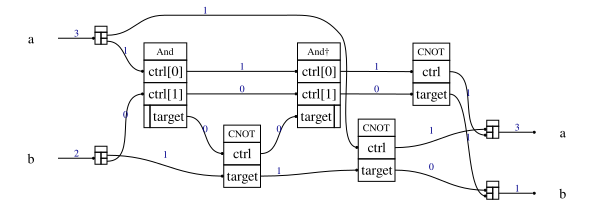

In [11]:
from qualtran.drawing import ClassicalSimGraphDrawer

# mod 2^2=4で計算
drawer = ClassicalSimGraphDrawer(Add(QUInt(2)).decompose_bloq(), vals=dict(a=3, b=2))
drawer.get_svg()

In [12]:
QUInt(8).to_bits(254)

[1, 1, 1, 1, 1, 1, 1, 0]

In [16]:
from qualtran import QFxp

@frozen
class DoubleFxp(Bloq):
    """Bloq with a QFxp of 4 bits (0 int, 4 frac).
    
    This bloq doubles the input value inplace, discarding any overflow
    """
    num_frac: int = 4

    @property
    def signature(self) -> Signature:
        return Signature.build_from_dtypes(x=QFxp(self.num_frac, self.num_frac))

    def on_classical_vals(self, x) -> dict[str, "ClassicalValT"]:
        """Double the input value, discarding overflow"""
        return {"x": (x * 2) % (2 ** self.num_frac)}



bloq_with_qfxp = DoubleFxp()
x_float = 0.25
x_as_int = QFxp(4, 4).to_fixed_width_int(x_float)
(x_out_as_int,) = bloq_with_qfxp.call_classically(x=x_as_int)
x_out_float = QFxp(4, 4).float_from_fixed_width_int(x_out_as_int)
assert x_out_float == 0.5